# Project 2.5 — System Identification of a Nonlinear Dynamical System

**Course:** Machine Learning for Vision and Multimedia (Polito, 2025/26) — project §2.5.
**Dataset:** Cortical Responses Evoked by Wrist Joint Manipulation (Vlaar et al., IEEE TNSRE 2018).

Goal: identify a SISO model `y[k] = f(u[·], y[·])` relating the wrist handle angle (`u`) to the top-SNR ICA component of the EEG (`y`).

* **Phase 1** — train NNARX, simple RNN, LSTM, GRU.
* **Phase 2** — sweep architecture sizes (hidden size, layers).
* **Phase 3** — compare simulation accuracy, training time, parameter count, FLOPs/sample.

Two datasets are supported via `CFG["dataset"]`:
* `"small"` — pre-averaged, downsampled, scaled, time-delayed (`Benchmark_EEG_small/Benchmark_EEG_small.mat`).
* `"medium"` — raw `[M, P, N_raw]` per subject; the notebook reproduces the small-version preprocessing in Python (`Benchmark_EEG_medium/Benchmark_EEG_medium.mat`).

Two splits are supported via `CFG["split"]`:
* `"within"` — within-participant holdout by realization index.
* `"loso"` — leave-one-subject-out: one subject is fully held out for test, realizations of the remaining subjects supply train + val.

## 1. Imports and device

In [140]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.10.0+cu128


## 2. Configuration

All hyperparameters in one dict so Phase 2 sweeps are just copies of this with values changed.

In [ ]:
CFG = {
    "fs": 256,                 # sample rate (Hz) after downsampling
    # Dataset + split
    "dataset": "medium",       # "small" | "medium"
    "split":   "loso",         # "within" | "loso"
    # NNARX regressor sizes
    "narx_nu": 10,             # number of past inputs (including u[k])
    "narx_ny": 10,             # number of past outputs
    "narx_hidden": (64, 64),   # MLP hidden widths
    # NNARX architecture / parameterization
    "narx_act":             "gelu",        # "tanh" | "relu" | "gelu"
    "narx_dropout":         0.1,           # dropout p between hidden layers (0 disables)
    "narx_skip":            True,          # add linear input->output skip (ARX baseline)
    "narx_residual":        True,          # predict Δy[k]=y[k]-y[k-1] then integrate at sim time
    "narx_u_feats":         ("du",),       # u feature channels: subset of {"du","usq"}; () for u-only
    # NNARX training-time robustness
    "narx_y_noise_std":     0.1,           # Gaussian noise on past-y (1-step branch)
    "narx_val_every":       2,             # epochs between simulation-based val checks
    "narx_patience_checks": 8,             # consecutive sim-eval checks w/o improvement -> early stop
    "narx_weight_decay":    1e-4,          # NNARX-specific L2
    "narx_grad_clip":       1.0,           # gradient norm clip (None disables)
    "narx_kstep_schedule":  ((0, 1), (20, 5), (40, 10), (80, 20)),  # (epoch_threshold, kstep) curriculum
    "narx_lr_schedule":     "cosine",      # "cosine" | None
    "narx_ensemble":        3,             # number of independent runs averaged at sim time
    # Recurrent models
    "rec_hidden": 64,
    "rec_layers": 1,
    # Training
    "epochs_narx": 200,
    "epochs_rec": 200,
    "batch_narx": 512,
    "lr": 1e-3,
    "weight_decay": 0.0,
    # Within-participant split (indices into M=7 realizations per participant)
    "train_real_idx": [0, 1, 2, 3, 4],
    "val_real_idx":   [5],
    "test_real_idx":  [6],
    # LOSO split
    "loso_test_subject":  0,        # index of the held-out subject (0..S-1)
    "loso_val_real_idx":  [5, 6],   # realizations from training subjects used as val
}
CFG

## 3. Load the dataset

In [142]:
def find_mat_file(filename):
    stem = filename.replace(".mat", "")
    candidates = [Path(stem) / filename, Path(filename)]
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for sub in kaggle_root.iterdir():
            for p in sub.rglob(filename):
                candidates.append(p)
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found in any expected location.")


def load_small(mat_path):
    mat = sio.loadmat(str(mat_path), simplify_cells=True)
    data = mat["data"]
    u = np.asarray(data["u"], dtype=np.float32)   # [S, M, N]
    y = np.asarray(data["y"], dtype=np.float32)
    return u, y


def load_medium(mat_path, ds=8):
    """Python port of Load_Plot_EEG_2.m: average over periods, downsample,
    per-subject zero-mean/scale, delay input by 5 samples. Output shape [S, M, N]."""
    mat = sio.loadmat(str(mat_path), simplify_cells=True)
    eeg = mat["EEGdata"]  # iterable of per-subject dicts with 'angle', 'comp'
    u_list, y_list = [], []
    for rec in eeg:
        angle = np.asarray(rec["angle"], dtype=np.float32)  # [M, P, N_raw]
        comp  = np.asarray(rec["comp"],  dtype=np.float32)
        u_list.append(angle[:, :, ::ds].mean(axis=1))       # -> [M, N]
        y_list.append(comp[:,  :, ::ds].mean(axis=1))
    u = np.stack(u_list, axis=0)  # [S, M, N]
    y = np.stack(y_list, axis=0)
    # zero-mean per realization, scale per subject by mean-of-per-realization std
    u = u - u.mean(axis=-1, keepdims=True)
    y = y - y.mean(axis=-1, keepdims=True)
    u_scale = u.std(axis=-1, ddof=1).mean(axis=-1, keepdims=True)   # [S, 1]
    y_scale = y.std(axis=-1, ddof=1).mean(axis=-1, keepdims=True)
    u = u / u_scale[:, :, None]
    y = y / y_scale[:, :, None]
    # response is delayed, so also delay the input (matches MATLAB circshift(...,5,3))
    u = np.roll(u, shift=5, axis=-1)
    return u.astype(np.float32), y.astype(np.float32)


if CFG["dataset"] == "small":
    mat_path = find_mat_file("Benchmark_EEG_small.mat")
    print("Loading small:", mat_path)
    u_all, y_all = load_small(mat_path)
elif CFG["dataset"] == "medium":
    mat_path = find_mat_file("Benchmark_EEG_medium.mat")
    print("Loading medium:", mat_path)
    u_all, y_all = load_medium(mat_path)
else:
    raise ValueError(f"unknown dataset {CFG['dataset']!r}")

S, M, N = u_all.shape
print(f"participants S={S}, realizations M={M}, samples N={N}, "
      f"fs={CFG['fs']} Hz -> segment length {N/CFG['fs']:.2f}s")

Loading medium: /kaggle/input/datasets/fabiobrugiafreddo/benchmark-eeg-medium/Benchmark_EEG_medium.mat
participants S=10, realizations M=7, samples N=256, fs=256 Hz -> segment length 1.00s


Quick look at one participant / one realization — time domain.

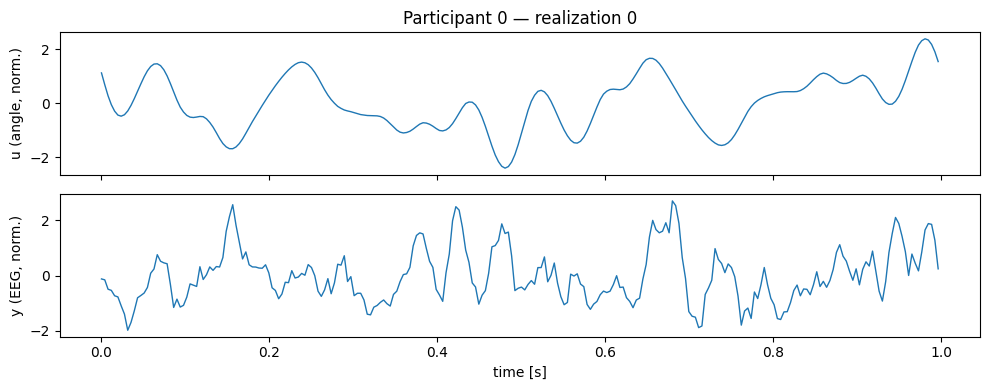

In [143]:
t = np.arange(N) / CFG["fs"]
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t, u_all[0, 0], lw=1); axes[0].set_ylabel("u (angle, norm.)")
axes[1].plot(t, y_all[0, 0], lw=1); axes[1].set_ylabel("y (EEG, norm.)")
axes[1].set_xlabel("time [s]")
axes[0].set_title("Participant 0 — realization 0")
plt.tight_layout(); plt.show()

## 4. Train / val / test split

Two modes, selected by `CFG["split"]`:

* **`"within"`** — per subject: 5 realizations → train, 1 → val, 1 → test. Model has seen every subject during training.
* **`"loso"`** — subject `loso_test_subject` is fully held out for test. Realizations in `loso_val_real_idx` from the remaining `S-1` subjects go to val; the rest go to train. Model has never seen the test subject.

Both modes produce flat `[num_sequences, N]` arrays so downstream code is unchanged.

In [144]:
def make_split(u_all, y_all, cfg):
    def take(idxs):
        u = u_all[:, idxs, :].reshape(-1, u_all.shape[-1])
        y = y_all[:, idxs, :].reshape(-1, y_all.shape[-1])
        return u, y
    return take(cfg["train_real_idx"]), take(cfg["val_real_idx"]), take(cfg["test_real_idx"])


def make_loso_split(u_all, y_all, cfg):
    S, M, N = u_all.shape
    test_s  = int(cfg["loso_test_subject"])
    val_idx = list(cfg["loso_val_real_idx"])
    tr_idx  = [m for m in range(M) if m not in val_idx]
    # test: every realization of the held-out subject
    u_te = u_all[test_s].reshape(-1, N)
    y_te = y_all[test_s].reshape(-1, N)
    # train + val: all other subjects, split by realization index
    keep  = [s for s in range(S) if s != test_s]
    u_oth = u_all[keep]   # [S-1, M, N]
    y_oth = y_all[keep]
    u_tr = u_oth[:, tr_idx,  :].reshape(-1, N)
    y_tr = y_oth[:, tr_idx,  :].reshape(-1, N)
    u_va = u_oth[:, val_idx, :].reshape(-1, N)
    y_va = y_oth[:, val_idx, :].reshape(-1, N)
    return (u_tr, y_tr), (u_va, y_va), (u_te, y_te)


if CFG["split"] == "within":
    (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_split(u_all, y_all, CFG)
    print(f"[within-participant] train: {u_tr.shape}, val: {u_va.shape}, test: {u_te.shape}")
elif CFG["split"] == "loso":
    (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_loso_split(u_all, y_all, CFG)
    print(f"[LOSO  test_subject={CFG['loso_test_subject']}] "
          f"train: {u_tr.shape}, val: {u_va.shape}, test: {u_te.shape}")
else:
    raise ValueError(f"unknown split {CFG['split']!r}")

[LOSO  test_subject=0] train: (45, 256), val: (18, 256), test: (7, 256)


## 5. Metrics

Following the nonlinear-benchmarks convention:

* **NRMSE** = RMSE(y, ŷ) / std(y)
* **VAF** = 100 · (1 − var(y − ŷ) / var(y))  (percentage)

In [145]:
def nrmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return float(rmse / (y_true.std() + 1e-12))

def vaf(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(100.0 * (1.0 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-12)))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. NNARX

Regressor at step k:

`x[k] = [u[k], u[k-1], …, u[k-nu+1], y[k-1], …, y[k-ny]]` (size `nu + ny`)

Trained teacher-forced. At test time we **simulate**: the first `max(nu, ny)` samples of `y` are used as warm-up from the true signal, then predictions are fed back as inputs.

In [ ]:
def make_u_feats(u, u_feats=()):
    """u: 1D [T]  ->  [T, F] with channels [u, du, u**2] subset.
       u_feats subset of {'du','usq'}; F = 1 + len(u_feats)."""
    u = np.asarray(u, dtype=np.float32)
    cols = [u]
    if "du" in u_feats:
        du = np.empty_like(u); du[0] = 0.0; du[1:] = u[1:] - u[:-1]
        cols.append(du)
    if "usq" in u_feats:
        cols.append(u * u)
    return np.stack(cols, axis=-1)


def build_narx_windows(u_seqs, y_seqs, nu, ny, residual=False, u_feats=()):
    """1-step teacher-forced regressors. Target Δy when residual=True else y."""
    xs, ts = [], []
    L = max(nu, ny)
    for u, y in zip(u_seqs, y_seqs):
        uf = make_u_feats(u, u_feats)              # [T, F]
        for k in range(L, len(u)):
            u_win = uf[k-nu+1:k+1][::-1].reshape(-1)   # nu*F (time reversed, then flat)
            y_win = y[k-ny:k][::-1]
            xs.append(np.concatenate([u_win, y_win]))
            ts.append(y[k] - y[k-1] if residual else y[k])
    X = np.stack(xs).astype(np.float32)
    t = np.asarray(ts, dtype=np.float32)[:, None]
    return X, t


def build_narx_rollout(u_seqs, y_seqs, nu, ny, kstep, u_feats=()):
    """k-step rollout windows with multi-channel u features.
       U_win [B, nu+kstep-1, F], Y_warm [B, ny], Y_tgt [B, kstep] (raw y)."""
    Us, Yw, Yt = [], [], []
    L = max(nu, ny)
    for u, y in zip(u_seqs, y_seqs):
        uf = make_u_feats(u, u_feats)
        Nseq = len(u)
        for k in range(L, Nseq - kstep + 1):
            Us.append(uf[k-nu+1 : k+kstep])         # [nu+kstep-1, F]
            Yw.append(y[k-ny : k])
            Yt.append(y[k : k+kstep])
    return (np.stack(Us).astype(np.float32),
            np.stack(Yw).astype(np.float32),
            np.stack(Yt).astype(np.float32))


_ACTS = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU}


class NNARX(nn.Module):
    def __init__(self, nu, ny, hidden=(64, 64), act="tanh", residual=False,
                 dropout=0.0, skip=False, u_feats=()):
        super().__init__()
        self.nu, self.ny = nu, ny
        self.residual = residual
        self.u_feats = tuple(u_feats)
        self.n_u_feats = 1 + len(self.u_feats)
        in_dim = nu * self.n_u_feats + ny
        act_cls = _ACTS[act.lower()]
        layers = []
        dims = [in_dim] + list(hidden)
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), act_cls()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers += [nn.Linear(dims[-1], 1)]
        self.net = nn.Sequential(*layers)
        self.skip = nn.Linear(in_dim, 1) if skip else None
        self.in_dim = in_dim

    def _head(self, x):
        out = self.net(x)
        if self.skip is not None:
            out = out + self.skip(x)
        return out

    def forward(self, x):
        return self._head(x)

    @torch.no_grad()
    def simulate(self, u_seq, y_warmup):
        dev = next(self.parameters()).device
        u = np.asarray(u_seq, dtype=np.float32)
        uf = make_u_feats(u, self.u_feats)
        Nseq = len(u)
        L = max(self.nu, self.ny)
        y_hat = np.zeros(Nseq, dtype=np.float32)
        y_hat[:L] = np.asarray(y_warmup, dtype=np.float32)[:L]
        self.eval()
        for k in range(L, Nseq):
            u_win = uf[k-self.nu+1:k+1][::-1].reshape(-1)
            x = np.concatenate([u_win, y_hat[k-self.ny:k][::-1]])
            x_t = torch.from_numpy(x).float().unsqueeze(0).to(dev)
            out = float(self._head(x_t).cpu().numpy()[0, 0])
            y_hat[k] = (y_hat[k-1] + out) if self.residual else out
        return y_hat

    def rollout(self, U_win, Y_warm, kstep):
        """U_win [B, nu+kstep-1, F], Y_warm [B, ny] -> preds [B, kstep] (raw y)."""
        y_buf = Y_warm
        preds = []
        for j in range(kstep):
            u_slice = U_win[:, j : j + self.nu, :]                       # [B, nu, F]
            u_flat  = u_slice.flip(1).reshape(u_slice.size(0), -1)       # reverse time, flatten
            x = torch.cat([u_flat, y_buf.flip(-1)], dim=-1)
            out = self._head(x).squeeze(-1)
            y_pred = (y_buf[:, -1] + out) if self.residual else out
            preds.append(y_pred)
            y_buf = torch.cat([y_buf[:, 1:], y_pred.unsqueeze(-1)], dim=-1)
        return torch.stack(preds, dim=-1)

## 7. Simple RNN / LSTM / GRU

Closed-loop by construction: input is `u[k]`, hidden state carries the dynamics, linear head outputs `y[k]`.
A forward pass on a test sequence **is** the simulation — no teacher forcing needed at evaluation.

In [147]:
class SeqModel(nn.Module):
    def __init__(self, kind="lstm", hidden=64, layers=1):
        super().__init__()
        cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind.lower()]
        kwargs = dict(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        if kind.lower() == "rnn":
            kwargs["nonlinearity"] = "tanh"
        self.rnn = cls(**kwargs)
        self.head = nn.Linear(hidden, 1)
        self.kind = kind; self.hidden = hidden; self.layers = layers

    def forward(self, u):
        h, _ = self.rnn(u)
        return self.head(h)

## 8. Training loops

In [ ]:
def train_narx(model, u_tr, y_tr, u_va, y_va, epochs, batch, lr, weight_decay=0.0,
               y_noise_std=0.0, val_every=5, patience_checks=5,
               kstep_schedule=((0, 1),), lr_schedule=None, grad_clip=None):
    """Train NNARX with closed-loop tweaks:
       - 1-step branch: TF + Gaussian noise on past-y regressor.
       - k-step branch: differentiable closed-loop rollout, propagating model
         predictions back into past-y. Curriculum picks the largest reached k.
       - Cosine LR schedule (optional). Gradient norm clip (optional).
       - Periodic simulation-mode val + best-state restore on val sim NRMSE."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
                 if lr_schedule == "cosine" else None)
    loss_fn = nn.MSELoss()

    feats = model.u_feats
    X_tr1, t_tr1 = build_narx_windows(u_tr, y_tr, model.nu, model.ny,
                                      residual=model.residual, u_feats=feats)
    dl1 = DataLoader(TensorDataset(torch.from_numpy(X_tr1), torch.from_numpy(t_tr1)),
                     batch_size=batch, shuffle=True, drop_last=False)
    # past-y position in regressor (after u features)
    y_lo = model.nu * model.n_u_feats
    y_hi = y_lo + model.ny

    rollout_cache = {}
    def get_rollout_loader(k):
        if k in rollout_cache: return rollout_cache[k]
        U, Yw, Yt = build_narx_rollout(u_tr, y_tr, model.nu, model.ny, k, u_feats=feats)
        dl = DataLoader(TensorDataset(torch.from_numpy(U), torch.from_numpy(Yw),
                                      torch.from_numpy(Yt)),
                        batch_size=batch, shuffle=True, drop_last=False)
        rollout_cache[k] = dl
        return dl

    sched = sorted(kstep_schedule)
    def current_kstep(ep):
        cur = 1
        for thr, k in sched:
            if ep >= thr: cur = k
        return cur

    history = {"train": [], "val_sim_nrmse": [], "kstep": []}
    best_nrmse, best_state, bad_checks = float("inf"), None, 0
    t0 = time.time()

    for ep in range(epochs):
        kstep = current_kstep(ep)
        history["kstep"].append(kstep)
        model.train(); losses = []
        if kstep <= 1:
            for xb, tb in dl1:
                xb, tb = xb.to(DEVICE), tb.to(DEVICE)
                if y_noise_std > 0.0:
                    xb = xb.clone()
                    xb[:, y_lo:y_hi] += torch.randn_like(xb[:, y_lo:y_hi]) * y_noise_std
                opt.zero_grad()
                loss = loss_fn(model(xb), tb); loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                opt.step()
                losses.append(loss.item())
        else:
            dl_k = get_rollout_loader(kstep)
            for U_b, Yw_b, Yt_b in dl_k:
                U_b  = U_b.to(DEVICE)
                Yw_b = Yw_b.to(DEVICE)
                Yt_b = Yt_b.to(DEVICE)
                if y_noise_std > 0.0:
                    Yw_b = Yw_b + torch.randn_like(Yw_b) * y_noise_std
                opt.zero_grad()
                preds = model.rollout(U_b, Yw_b, kstep)
                loss = loss_fn(preds, Yt_b); loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                opt.step()
                losses.append(loss.item())

        if scheduler is not None: scheduler.step()
        history["train"].append(float(np.mean(losses)))

        if (ep + 1) % val_every == 0 or ep == epochs - 1:
            y_hat, y_true = eval_narx(model, u_va, y_va)
            v_nrmse = nrmse(y_true, y_hat)
            history["val_sim_nrmse"].append((ep + 1, v_nrmse))
            improved = v_nrmse < best_nrmse - 1e-4
            if improved:
                best_nrmse = v_nrmse
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad_checks = 0; tag = "(best)"
            else:
                bad_checks += 1; tag = f"(no improve {bad_checks}/{patience_checks})"
            lr_now = opt.param_groups[0]["lr"]
            print(f"ep {ep+1:3d}/{epochs}  k={kstep}  lr={lr_now:.2e}  "
                  f"train {history['train'][-1]:.4e}  val sim NRMSE {v_nrmse:.4f}  {tag}")
            if bad_checks >= patience_checks:
                print(f"early stop at epoch {ep+1} (best val sim NRMSE = {best_nrmse:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, time.time() - t0


def train_seq(model, u_tr, y_tr, u_va, y_va, epochs, lr, weight_decay=0.0):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    U_tr = torch.from_numpy(u_tr).float().unsqueeze(-1).to(DEVICE)
    Y_tr = torch.from_numpy(y_tr).float().unsqueeze(-1).to(DEVICE)
    U_va = torch.from_numpy(u_va).float().unsqueeze(-1).to(DEVICE)
    Y_va = torch.from_numpy(y_va).float().unsqueeze(-1).to(DEVICE)
    history = {"train": [], "val": []}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(U_tr), Y_tr); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(U_va), Y_va).item()
        history["train"].append(loss.item()); history["val"].append(vloss)
        if (ep + 1) % max(1, epochs // 10) == 0 or ep == 0:
            print(f"ep {ep+1:3d}/{epochs}  train {loss.item():.4e}  val {vloss:.4e}")
    return history, time.time() - t0

## 9. Simulation-mode evaluation

In [149]:
def eval_narx(model, u_seqs, y_seqs):
    preds, truths = [], []
    for u, y in zip(u_seqs, y_seqs):
        L = max(model.nu, model.ny)
        preds.append(model.simulate(u, y[:L]))
        truths.append(np.asarray(y, dtype=np.float32))
    return np.concatenate(preds), np.concatenate(truths)

def eval_seq(model, u_seqs, y_seqs):
    model.eval()
    U = torch.from_numpy(u_seqs).float().unsqueeze(-1).to(DEVICE)
    with torch.no_grad():
        pred = model(U).squeeze(-1).cpu().numpy()
    return pred.reshape(-1), np.asarray(y_seqs, dtype=np.float32).reshape(-1)

## 10. Parameters and FLOPs per output sample

Analytic counts (one multiply-add = 2 FLOPs). Recurrent cells aren't handled well by `ptflops`, so we compute them in closed form.

In [ ]:
def flops_per_sample(model):
    if isinstance(model, NNARX):
        in_dim = model.nu * model.n_u_feats + model.ny
        f, prev = 0, in_dim
        for layer in model.net:
            if isinstance(layer, nn.Linear):
                f += 2 * prev * layer.out_features + layer.out_features
                prev = layer.out_features
        if model.skip is not None:
            f += 2 * in_dim * 1 + 1
        return f
    if isinstance(model, SeqModel):
        H, L, kind = model.hidden, model.layers, model.kind.lower()
        gates = {"rnn": 1, "gru": 3, "lstm": 4}[kind]
        # per step, layer 1: gates*(input->hidden + hidden->hidden) + biases + nonlinearities
        f_layer1 = 2 * gates * (1 * H + H * H) + gates * H
        f_other  = 2 * gates * (H * H + H * H) + gates * H
        total = f_layer1 + (L - 1) * f_other
        # per-step elementwise ops for gated cells (tanh/sigmoid/hadamard)
        if kind == "lstm": total += 5 * H
        elif kind == "gru": total += 3 * H
        total += 2 * H * 1 + 1                 # linear head
        return total
    return None

## 11. Phase 1 — run one model end-to-end

`run_nnarx` / `run_seq` wrap training, simulation-mode evaluation on the test realization, param and FLOPs counts, and a simulated-vs-true plot.

In [ ]:
def plot_sim(y_true, y_pred, title, n=None):
    if n is None:
        n = min(len(y_true), 4 * int(CFG["fs"]))
    t = np.arange(n) / CFG["fs"]
    plt.figure(figsize=(10, 3))
    plt.plot(t, y_true[:n], label="true", lw=1)
    plt.plot(t, y_pred[:n], label="sim",  lw=1, alpha=0.8)
    plt.xlabel("time [s]"); plt.ylabel("y"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()


RESULTS = {}


def _make_nnarx(cfg):
    return NNARX(cfg["narx_nu"], cfg["narx_ny"],
                 hidden=tuple(cfg["narx_hidden"]),
                 act=cfg.get("narx_act", "tanh"),
                 residual=cfg.get("narx_residual", False),
                 dropout=cfg.get("narx_dropout", 0.0),
                 skip=cfg.get("narx_skip", False),
                 u_feats=tuple(cfg.get("narx_u_feats", ())))


def _train_one_nnarx(cfg, seed_offset):
    torch.manual_seed(SEED + seed_offset); np.random.seed(SEED + seed_offset)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + seed_offset)
    model = _make_nnarx(cfg)
    history, elapsed = train_narx(
        model, u_tr, y_tr, u_va, y_va,
        epochs=cfg["epochs_narx"], batch=cfg["batch_narx"],
        lr=cfg["lr"],
        weight_decay=cfg.get("narx_weight_decay", cfg.get("weight_decay", 0.0)),
        y_noise_std=cfg.get("narx_y_noise_std", 0.0),
        val_every=cfg.get("narx_val_every", 5),
        patience_checks=cfg.get("narx_patience_checks", 5),
        kstep_schedule=cfg.get("narx_kstep_schedule", ((0, 1),)),
        lr_schedule=cfg.get("narx_lr_schedule", None),
        grad_clip=cfg.get("narx_grad_clip", None),
    )
    return model, history, elapsed


def run_nnarx(cfg, tag="nnarx"):
    n_ens = int(cfg.get("narx_ensemble", 1))
    # Fan out training. For ensemble n>1, simulate each on test and average.
    sim_per_model = []
    total_t = 0.0
    last_model, last_history = None, None
    for i in range(n_ens):
        if n_ens > 1:
            print(f"\n[ensemble member {i+1}/{n_ens}]")
        model, history, elapsed = _train_one_nnarx(cfg, seed_offset=i)
        if i == 0:
            print(f"NNARX params: {count_params(model):,}  "
                  f"residual={model.residual}  skip={model.skip is not None}  "
                  f"act={cfg.get('narx_act','tanh')}  "
                  f"u_feats={model.u_feats}  ensemble={n_ens}")
        seq_preds = []
        for u_seq, y_seq in zip(u_te, y_te):
            L = max(model.nu, model.ny)
            seq_preds.append(model.simulate(u_seq, y_seq[:L]))
        sim_per_model.append(np.concatenate(seq_preds))
        total_t += elapsed
        last_model, last_history = model, history

    y_hat = np.mean(np.stack(sim_per_model, axis=0), axis=0)
    y_true = np.concatenate([np.asarray(y, dtype=np.float32) for y in y_te])
    res = dict(model="NNARX", params=count_params(last_model),
               flops_per_sample=flops_per_sample(last_model) * n_ens,
               train_time_s=total_t, ensemble=n_ens,
               nrmse_sim=nrmse(y_true, y_hat), vaf_sim=vaf(y_true, y_hat),
               history=last_history)
    print(f"test sim NRMSE={res['nrmse_sim']:.4f}, VAF={res['vaf_sim']:.2f}%, "
          f"train_time={total_t:.1f}s, FLOPs/sample={res['flops_per_sample']:,}")
    plot_sim(y_true, y_hat, title="NNARX — simulation on test (first seconds)")
    return last_model, res


def run_seq(kind, cfg):
    model = SeqModel(kind=kind, hidden=cfg["rec_hidden"], layers=cfg["rec_layers"])
    print(f"{kind.upper()} params: {count_params(model):,}")
    history, elapsed = train_seq(model, u_tr, y_tr, u_va, y_va,
                                 epochs=cfg["epochs_rec"],
                                 lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    y_hat, y_true = eval_seq(model, u_te, y_te)
    res = dict(model=kind.upper(), params=count_params(model),
               flops_per_sample=flops_per_sample(model),
               train_time_s=elapsed,
               nrmse_sim=nrmse(y_true, y_hat), vaf_sim=vaf(y_true, y_hat),
               history=history)
    print(f"test sim NRMSE={res['nrmse_sim']:.4f}, VAF={res['vaf_sim']:.2f}%, "
          f"train_time={elapsed:.1f}s, FLOPs/sample={res['flops_per_sample']:,}")
    plot_sim(y_true, y_hat, title=f"{kind.upper()} — simulation on test (first seconds)")
    return model, res

### NNARX

NNARX params: 5,569
ep   5/200  train 2.1425e-01  val sim NRMSE 1.0944  (best)
ep  10/200  train 2.0529e-01  val sim NRMSE 1.0295  (best)
ep  15/200  train 2.0360e-01  val sim NRMSE 0.9732  (best)
ep  20/200  train 2.0132e-01  val sim NRMSE 1.0928  (no improve 1/5)
ep  25/200  train 2.0141e-01  val sim NRMSE 1.0035  (no improve 2/5)
ep  30/200  train 2.0150e-01  val sim NRMSE 1.0131  (no improve 3/5)
ep  35/200  train 1.9960e-01  val sim NRMSE 0.9883  (no improve 4/5)
ep  40/200  train 1.9814e-01  val sim NRMSE 1.0370  (no improve 5/5)
early stop at epoch 40 (best val sim NRMSE = 0.9732)
test sim NRMSE=0.9813, VAF=3.71%, train_time=12.2s, FLOPs/sample=11,009


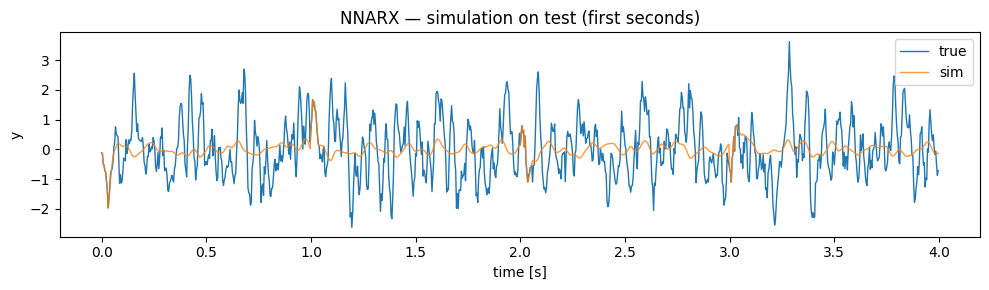

In [152]:
model_nnarx, RESULTS["nnarx"] = run_nnarx(CFG)

### Simple RNN

RNN params: 4,353
ep   1/200  train 1.0459e+00  val 9.2466e-01
ep  20/200  train 1.0447e+00  val 9.2323e-01
ep  40/200  train 1.0374e+00  val 9.1264e-01
ep  60/200  train 1.0311e+00  val 9.1246e-01
ep  80/200  train 1.0184e+00  val 9.1393e-01
ep 100/200  train 9.9009e-01  val 8.9359e-01
ep 120/200  train 9.7956e-01  val 9.2515e-01
ep 140/200  train 9.6694e-01  val 9.6180e-01
ep 160/200  train 9.6010e-01  val 8.9501e-01
ep 180/200  train 9.3735e-01  val 9.4200e-01
ep 200/200  train 9.2376e-01  val 9.6377e-01
test sim NRMSE=0.9761, VAF=4.72%, train_time=0.5s, FLOPs/sample=8,513


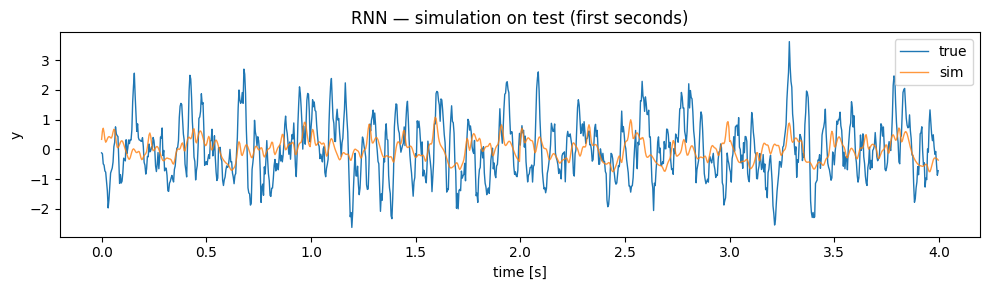

In [153]:
model_rnn, RESULTS["rnn"] = run_seq("rnn", CFG)

### LSTM

LSTM params: 17,217
ep   1/200  train 1.0484e+00  val 9.2634e-01
ep  20/200  train 1.0458e+00  val 9.2285e-01
ep  40/200  train 1.0449e+00  val 9.1966e-01
ep  60/200  train 1.0346e+00  val 9.0561e-01
ep  80/200  train 1.0211e+00  val 9.2246e-01
ep 100/200  train 1.0085e+00  val 9.5370e-01
ep 120/200  train 9.7169e-01  val 9.5756e-01
ep 140/200  train 9.4651e-01  val 9.9830e-01
ep 160/200  train 9.2998e-01  val 1.0003e+00
ep 180/200  train 9.0881e-01  val 1.0425e+00
ep 200/200  train 9.1401e-01  val 1.0244e+00
test sim NRMSE=0.9793, VAF=4.28%, train_time=0.6s, FLOPs/sample=33,985


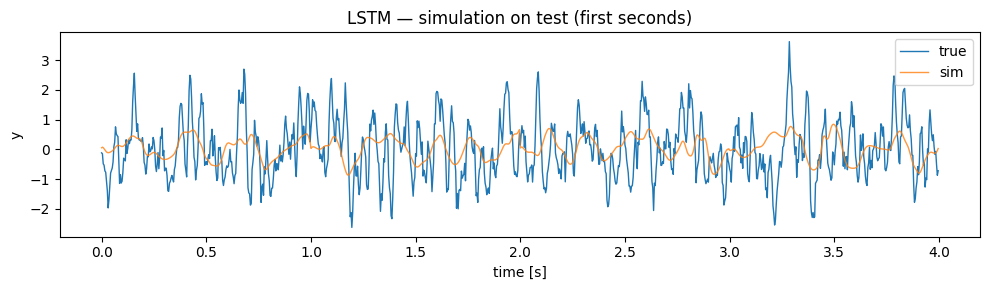

In [154]:
model_lstm, RESULTS["lstm"] = run_seq("lstm", CFG)

### GRU (optional in the brief)

GRU params: 12,929
ep   1/200  train 1.0557e+00  val 9.2930e-01
ep  20/200  train 1.0450e+00  val 9.2225e-01
ep  40/200  train 1.0441e+00  val 9.1948e-01
ep  60/200  train 1.0412e+00  val 9.1233e-01
ep  80/200  train 1.0227e+00  val 9.1117e-01
ep 100/200  train 1.0001e+00  val 9.4158e-01
ep 120/200  train 9.7181e-01  val 9.5562e-01
ep 140/200  train 9.6127e-01  val 9.9597e-01
ep 160/200  train 9.4070e-01  val 9.9485e-01
ep 180/200  train 9.1605e-01  val 9.9663e-01
ep 200/200  train 9.0570e-01  val 1.0330e+00
test sim NRMSE=1.0040, VAF=-0.47%, train_time=0.5s, FLOPs/sample=25,473


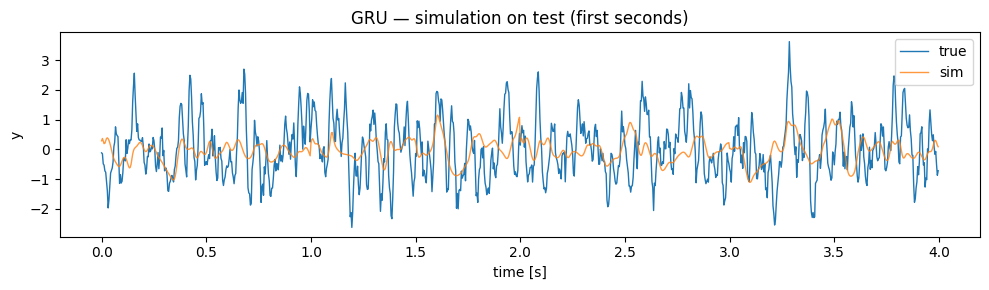

In [155]:
model_gru, RESULTS["gru"] = run_seq("gru", CFG)

## 12. Phase 2 — Architecture sweep

Small LSTM grid as an example (hidden width × number of layers). Extend to NNARX widths / RNN / GRU once you're happy with the pipeline.


--- LSTM hidden=32 layers=1 ---
LSTM params: 4,513
ep   1/100  train 1.0510e+00  val 9.2867e-01
ep  10/100  train 1.0459e+00  val 9.2572e-01
ep  20/100  train 1.0460e+00  val 9.2547e-01
ep  30/100  train 1.0456e+00  val 9.2462e-01
ep  40/100  train 1.0454e+00  val 9.2405e-01
ep  50/100  train 1.0452e+00  val 9.2332e-01
ep  60/100  train 1.0449e+00  val 9.2216e-01
ep  70/100  train 1.0445e+00  val 9.2067e-01
ep  80/100  train 1.0438e+00  val 9.1862e-01
ep  90/100  train 1.0421e+00  val 9.1508e-01
ep 100/100  train 1.0364e+00  val 9.0987e-01
test sim NRMSE=0.9955, VAF=0.90%, train_time=0.3s, FLOPs/sample=8,801


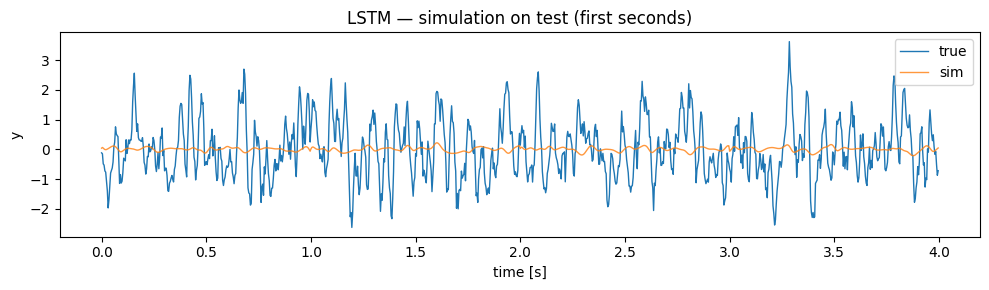


--- LSTM hidden=32 layers=2 ---
LSTM params: 12,961
ep   1/100  train 1.0976e+00  val 9.7023e-01
ep  10/100  train 1.0580e+00  val 9.3384e-01
ep  20/100  train 1.0468e+00  val 9.2552e-01
ep  30/100  train 1.0469e+00  val 9.2474e-01
ep  40/100  train 1.0463e+00  val 9.2414e-01
ep  50/100  train 1.0462e+00  val 9.2369e-01
ep  60/100  train 1.0460e+00  val 9.2322e-01
ep  70/100  train 1.0459e+00  val 9.2267e-01
ep  80/100  train 1.0457e+00  val 9.2170e-01
ep  90/100  train 1.0452e+00  val 9.1990e-01
ep 100/100  train 1.0431e+00  val 9.1684e-01
test sim NRMSE=0.9968, VAF=0.64%, train_time=0.3s, FLOPs/sample=25,313


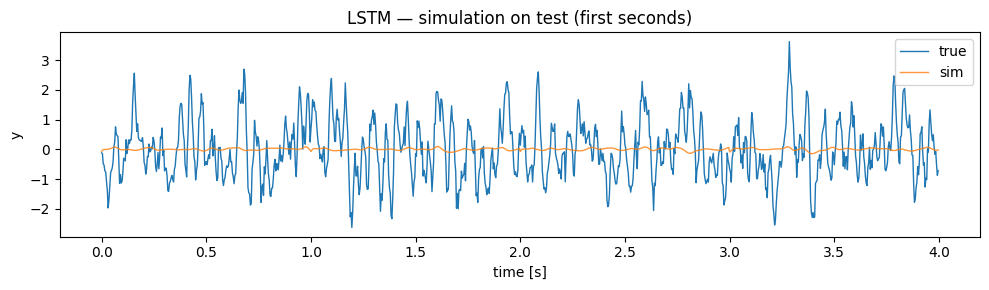


--- LSTM hidden=64 layers=1 ---
LSTM params: 17,217
ep   1/100  train 1.0494e+00  val 9.2542e-01
ep  10/100  train 1.0465e+00  val 9.2425e-01
ep  20/100  train 1.0458e+00  val 9.2267e-01
ep  30/100  train 1.0453e+00  val 9.2131e-01
ep  40/100  train 1.0448e+00  val 9.1821e-01
ep  50/100  train 1.0424e+00  val 9.1376e-01
ep  60/100  train 1.0355e+00  val 9.2460e-01
ep  70/100  train 1.0272e+00  val 9.3002e-01
ep  80/100  train 1.0219e+00  val 9.5937e-01
ep  90/100  train 1.0186e+00  val 9.5821e-01
ep 100/100  train 1.0165e+00  val 9.6934e-01
test sim NRMSE=0.9794, VAF=4.07%, train_time=0.3s, FLOPs/sample=33,985


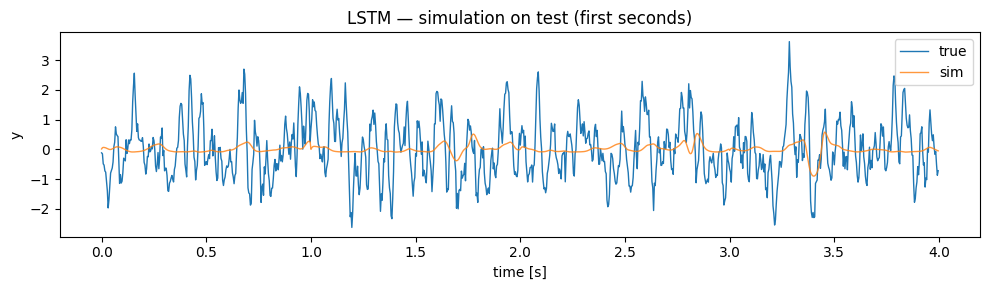


--- LSTM hidden=64 layers=2 ---
LSTM params: 50,497
ep   1/100  train 1.0472e+00  val 9.2514e-01
ep  10/100  train 1.0461e+00  val 9.2336e-01
ep  20/100  train 1.0459e+00  val 9.2300e-01
ep  30/100  train 1.0454e+00  val 9.2065e-01
ep  40/100  train 1.0424e+00  val 9.0630e-01
ep  50/100  train 1.0288e+00  val 9.2691e-01
ep  60/100  train 1.0234e+00  val 9.3892e-01
ep  70/100  train 1.0169e+00  val 9.4414e-01
ep  80/100  train 1.0105e+00  val 9.5708e-01
ep  90/100  train 1.0004e+00  val 9.8192e-01
ep 100/100  train 9.9200e-01  val 9.9011e-01
test sim NRMSE=0.9790, VAF=4.17%, train_time=0.3s, FLOPs/sample=99,777


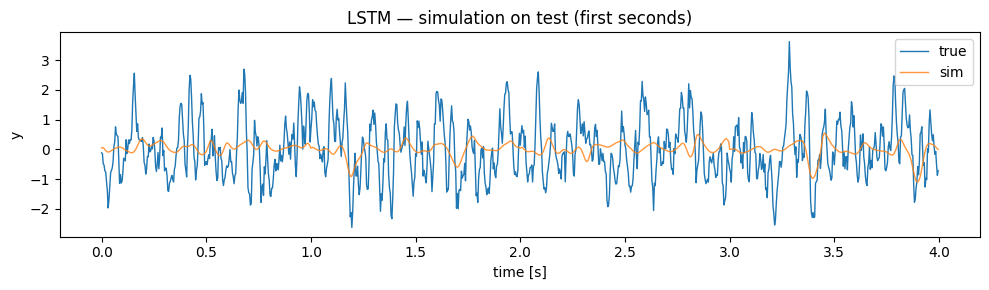


--- LSTM hidden=128 layers=1 ---
LSTM params: 67,201
ep   1/100  train 1.0477e+00  val 9.2459e-01
ep  10/100  train 1.0458e+00  val 9.2249e-01
ep  20/100  train 1.0451e+00  val 9.2006e-01
ep  30/100  train 1.0436e+00  val 9.1195e-01
ep  40/100  train 1.0353e+00  val 9.1422e-01
ep  50/100  train 1.0276e+00  val 9.2212e-01
ep  60/100  train 1.0214e+00  val 9.3379e-01
ep  70/100  train 1.0179e+00  val 1.1209e+00
ep  80/100  train 1.0209e+00  val 9.3555e-01
ep  90/100  train 1.0216e+00  val 9.4135e-01
ep 100/100  train 1.0165e+00  val 9.3802e-01
test sim NRMSE=0.9839, VAF=3.20%, train_time=0.5s, FLOPs/sample=133,505


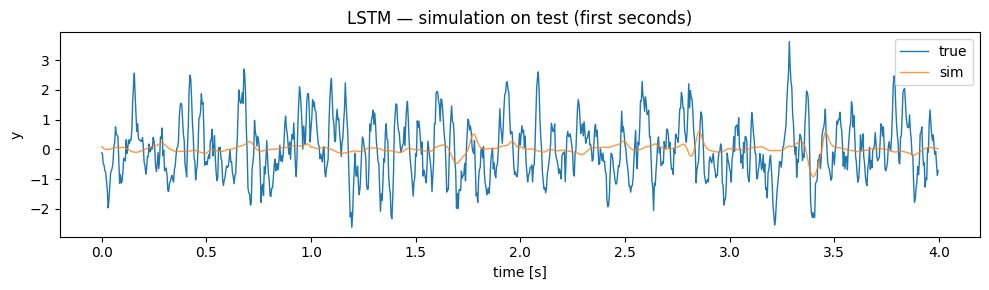


--- LSTM hidden=128 layers=2 ---
LSTM params: 199,297
ep   1/100  train 1.0471e+00  val 9.2465e-01
ep  10/100  train 1.0459e+00  val 9.2273e-01
ep  20/100  train 1.0442e+00  val 9.1324e-01
ep  30/100  train 1.0335e+00  val 9.1483e-01
ep  40/100  train 1.0277e+00  val 9.2652e-01
ep  50/100  train 1.0212e+00  val 9.3494e-01
ep  60/100  train 1.0068e+00  val 9.5672e-01
ep  70/100  train 9.9567e-01  val 9.6839e-01
ep  80/100  train 9.9285e-01  val 9.7784e-01
ep  90/100  train 9.8272e-01  val 9.9351e-01
ep 100/100  train 9.5975e-01  val 1.0128e+00
test sim NRMSE=0.9982, VAF=0.42%, train_time=1.1s, FLOPs/sample=396,161


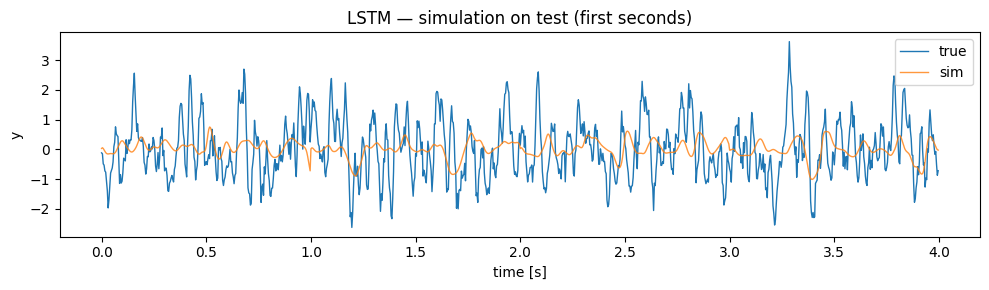


Phase 2 summary (sorted by sim NRMSE):
LSTM h= 64 L=2  NRMSE=0.979  VAF=4.2%  params=50,497  flops=99,777  t=0.3s
LSTM h= 64 L=1  NRMSE=0.979  VAF=4.1%  params=17,217  flops=33,985  t=0.3s
LSTM h=128 L=1  NRMSE=0.984  VAF=3.2%  params=67,201  flops=133,505  t=0.5s
LSTM h= 32 L=1  NRMSE=0.995  VAF=0.9%  params=4,513  flops=8,801  t=0.3s
LSTM h= 32 L=2  NRMSE=0.997  VAF=0.6%  params=12,961  flops=25,313  t=0.3s
LSTM h=128 L=2  NRMSE=0.998  VAF=0.4%  params=199,297  flops=396,161  t=1.1s


In [156]:
PHASE2 = []
for hidden in (32, 64, 128):
    for layers in (1, 2):
        cfg = dict(CFG); cfg["rec_hidden"] = hidden; cfg["rec_layers"] = layers
        cfg["epochs_rec"] = 100
        print(f"\n--- LSTM hidden={hidden} layers={layers} ---")
        _, res = run_seq("lstm", cfg)
        res["hidden"] = hidden; res["layers"] = layers
        PHASE2.append(res)

print("\nPhase 2 summary (sorted by sim NRMSE):")
for r in sorted(PHASE2, key=lambda r: r["nrmse_sim"]):
    print(f"LSTM h={r['hidden']:3d} L={r['layers']}  "
          f"NRMSE={r['nrmse_sim']:.3f}  VAF={r['vaf_sim']:.1f}%  "
          f"params={r['params']:,}  flops={r['flops_per_sample']:,}  "
          f"t={r['train_time_s']:.1f}s")

### Phase 2 — NNARX `(nu, ny)` sweep

Memory of past inputs/outputs sets the regressor capacity. fs=256 Hz on the medium dataset means 10 samples ≈ 39 ms — very short relative to typical EEG dynamics. Sweep a few orders to find the elbow.

In [ ]:
PHASE2_NARX = []
for nu, ny in [(10, 10), (20, 20), (20, 40), (40, 40)]:
    cfg = dict(CFG); cfg["narx_nu"] = nu; cfg["narx_ny"] = ny
    cfg["epochs_narx"] = 100
    # shrink curriculum to fit the shorter run
    cfg["narx_kstep_schedule"] = ((0, 1), (15, 5), (35, 10), (60, 20))
    print(f"\n--- NNARX nu={nu} ny={ny} ---")
    _, res = run_nnarx(cfg)
    res["nu"] = nu; res["ny"] = ny
    PHASE2_NARX.append(res)

print("\nPhase 2 NNARX summary (sorted by sim NRMSE):")
for r in sorted(PHASE2_NARX, key=lambda r: r["nrmse_sim"]):
    print(f"NNARX nu={r['nu']:3d} ny={r['ny']:3d}  "
          f"NRMSE={r['nrmse_sim']:.3f}  VAF={r['vaf_sim']:.1f}%  "
          f"params={r['params']:,}  flops={r['flops_per_sample']:,}  "
          f"t={r['train_time_s']:.1f}s")

## 13. Phase 3 — Comparison across model families

Head-to-head table and a simple params-vs-accuracy scatter.

model        params    flops/smp t_train[s]    NRMSE   VAF[%]
NNARX         5,569       11,009       12.2    0.981     3.71
RNN           4,353        8,513        0.5    0.976     4.72
LSTM         17,217       33,985        0.6    0.979     4.28
GRU          12,929       25,473        0.5    1.004    -0.47

saved: results/phase1_metrics.json


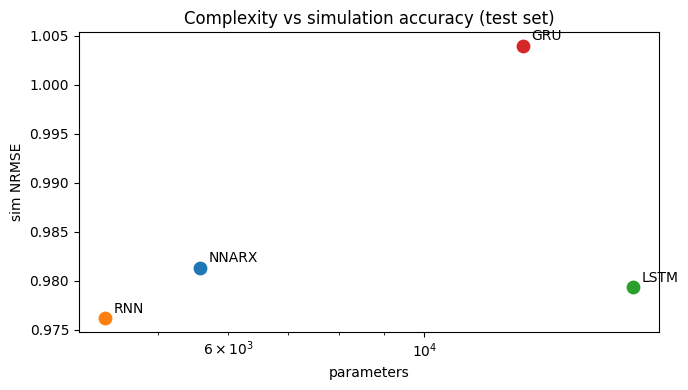

In [157]:
rows = []
for key in ("nnarx", "rnn", "lstm", "gru"):
    if key not in RESULTS: continue
    r = RESULTS[key]
    rows.append([r["model"], r["params"], r["flops_per_sample"], r["train_time_s"],
                 r["nrmse_sim"], r["vaf_sim"]])

print(f"{'model':<8} {'params':>10} {'flops/smp':>12} {'t_train[s]':>10} {'NRMSE':>8} {'VAF[%]':>8}")
for name, p, f, t, n, v in rows:
    print(f"{name:<8} {p:>10,} {f:>12,} {t:>10.1f} {n:>8.3f} {v:>8.2f}")

Path("results").mkdir(exist_ok=True)
with open("results/phase1_metrics.json", "w") as out:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "history"}
               for k, v in RESULTS.items()}, out, indent=2)
print("\nsaved: results/phase1_metrics.json")

fig, ax = plt.subplots(figsize=(7, 4))
for name, params, _flops, _t, n, _v in rows:
    ax.scatter(params, n, s=80)
    ax.annotate(name, (params, n), xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("parameters"); ax.set_ylabel("sim NRMSE")
ax.set_title("Complexity vs simulation accuracy (test set)")
plt.tight_layout(); plt.show()

## Next steps

* Extend Phase 2: sweep NNARX `(nu, ny, hidden)` and RNN/GRU sizes; log each run to `results/`.
* Add error-spectrum plot (FFT of `y - ŷ`) — the stimulus is near-periodic, residual spectra are very informative here.
* Cross-check NNARX FLOPs with `ptflops` as a sanity check on the manual formulas.

In [158]:
RUN_LOSO_CV = False

if RUN_LOSO_CV:
    assert CFG["split"] == "loso" and CFG["dataset"] == "medium", \
        "Outer LOSO loop expects dataset='medium', split='loso'."
    fold_rows = []
    for s in range(S):
        cfg = dict(CFG); cfg["loso_test_subject"] = s
        (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_loso_split(u_all, y_all, cfg)
        print(f"\n===== LOSO fold: test subject = {s} | "
              f"train {u_tr.shape}, val {u_va.shape}, test {u_te.shape} =====")
        _, r_narx = run_nnarx(cfg, tag=f"nnarx_s{s}")
        _, r_rnn  = run_seq("rnn",  cfg)
        _, r_lstm = run_seq("lstm", cfg)
        _, r_gru  = run_seq("gru",  cfg)
        for r in (r_narx, r_rnn, r_lstm, r_gru):
            fold_rows.append({"fold": s, **{k: v for k, v in r.items() if k != "history"}})

    import statistics as stats
    print("\nLOSO summary (mean ± std across folds):")
    by_model = {}
    for row in fold_rows:
        by_model.setdefault(row["model"], []).append(row)
    for name, rows in by_model.items():
        nr = [r["nrmse_sim"] for r in rows]
        vf = [r["vaf_sim"]   for r in rows]
        print(f"  {name:<6}  NRMSE {stats.mean(nr):.3f} ± {stats.pstdev(nr):.3f}  "
              f"VAF {stats.mean(vf):.2f} ± {stats.pstdev(vf):.2f}%")

    Path("results").mkdir(exist_ok=True)
    with open("results/loso_folds.json", "w") as f:
        json.dump(fold_rows, f, indent=2)
    print("\nsaved: results/loso_folds.json")
else:
    print("RUN_LOSO_CV=False — single-fold only. Set True to run all S folds.")

RUN_LOSO_CV=False — single-fold only. Set True to run all S folds.


## Next steps

* Leave-one-subject-out split — re-run with participant-level holdout for a stronger generalization check.
* Extend Phase 2: sweep NNARX `(nu, ny, hidden)` and RNN/GRU sizes; log each run to `results/`.
* Add error-spectrum plot (FFT of `y - ŷ`) — the stimulus is near-periodic, residual spectra are very informative here.
* Cross-check NNARX FLOPs with `ptflops` as a sanity check on the manual formulas.
